# 00- Environment Setup and Dataset Loading

### 1: Mounting drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working from: /content/drive/MyDrive/capstone


### 2: Installing required packages

In [ ]:
#Core ML / DL
!pip install torch torchvision torchaudio --quiet
!pip install transformers==4.40.0 --quiet
!pip install datasets==2.19.0 --quiet
!pip install accelerate --quiet

#OCR
!apt-get install -y tesseract-ocr tesseract-ocr-eng --quiet
!pip install pytesseract==0.3.10 --quiet

#Classical ML
!pip install scikit-learn --quiet

#Image processing
!pip install pillow opencv-python-headless --quiet

#Data & visualization
!pip install pandas matplotlib seaborn --quiet

#Utilities
!pip install tqdm --quiet

print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 45.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you 

### 3: Verifying all imports

In [ ]:
#Verifying all imports
import torch
import transformers
import datasets
import sklearn
import pytesseract
import cv2
import PIL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#CUDA must be true
#Checking GPU
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None — switch to GPU runtime!'}")
print(f"Transformers    : {transformers.__version__}")
print(f"Datasets        : {datasets.__version__}")
print(f"Tesseract path  : {pytesseract.get_tesseract_version()}")
print("All imports ok")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU device      : Tesla T4
Transformers    : 4.40.0
Datasets        : 2.19.0
Tesseract path  : 4.1.1
All imports ok


### 4: Seeds and config

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

#Fixed seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#Dataset config
#Using subset of RVL-CDIP: 400k images, 37GB. This is too large dataset, 5000 samples is enough for training and evaluation
SUBSET_TRAIN = 4000
SUBSET_VAL   = 500
SUBSET_TEST  = 500
IMG_SIZE     = (224, 224)

print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Train: {SUBSET_TRAIN} | Val: {SUBSET_VAL} | Test: {SUBSET_TEST}")

Seed: 42 | Device: cuda
Train: 4000 | Val: 500 | Test: 500


### 5: Load RVL-CDIP Dataset

In [ ]:
#Streaming mode is used to avoid storage waste
from datasets import load_dataset

#Streamming
train_ds = load_dataset("rvl_cdip", split="train", streaming=True)
val_ds   = load_dataset("rvl_cdip", split="validation", streaming=True)
test_ds  = load_dataset("rvl_cdip", split="test", streaming=True)

#Taking only the subset
train_ds = train_ds.take(SUBSET_TRAIN)
val_ds   = val_ds.take(SUBSET_VAL)
test_ds  = test_ds.take(SUBSET_TEST)

#Converting to list
print("Collecting train samples...")
train_list = list(train_ds)
print("Collecting val samples...")
val_list   = list(val_ds)
print("Collecting test samples...")
test_list  = list(test_ds)

#16 document categories in RVL-CDIP
LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']
NUM_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(train_list)} | Val: {len(val_list)} | Test: {len(test_list)}")
print(f"Classes ({NUM_CLASSES}): {LABEL_NAMES}")
print("Sample keys:", train_list[0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for rvl_cdip contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/rvl_cdip
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Train: 4000 | Val: 500 | Test: 500
Classes (16): ['letter', 'form', 'email', 'handwritten', 'advertisement', 'scientific report', 'scientific publication', 'specification', 'file folder', 'news article', 'budget', 'invoice', 'presentation', 'questionnaire', 'resume', 'memo']
Sample keys: dict_keys(['image', 'label'])


### 6: Visual check

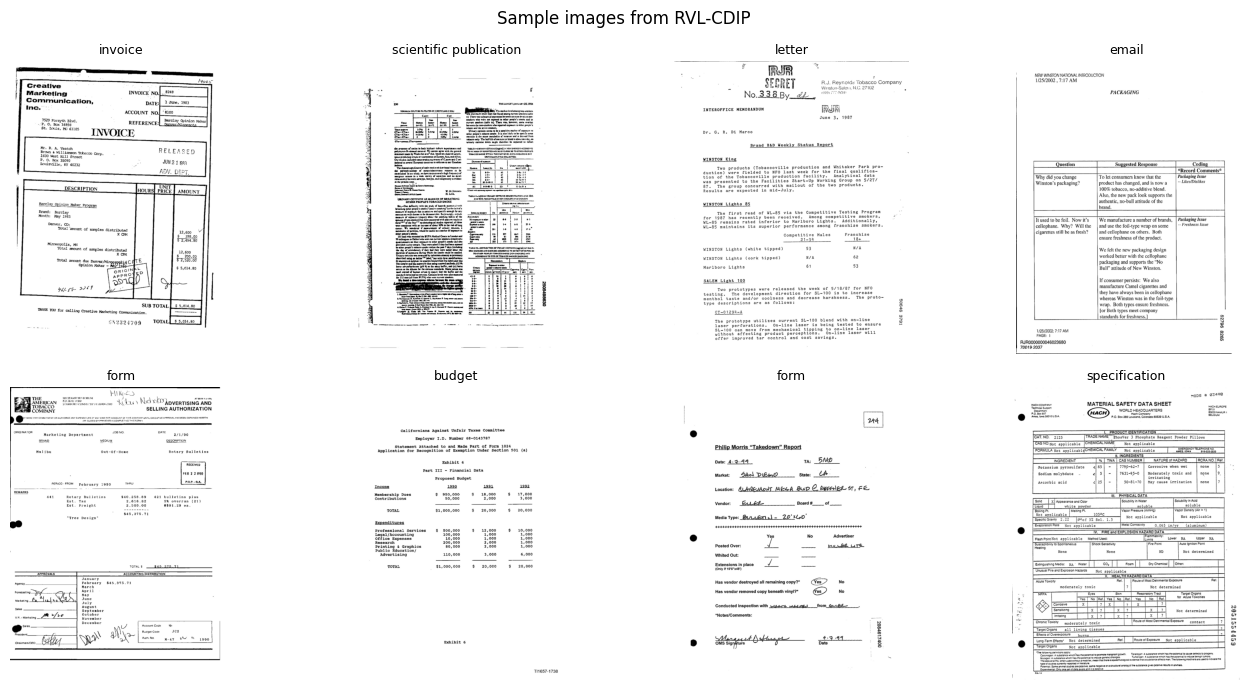

Sanity check saved to outputs/figures/


In [ ]:
#Ensuring that the actual images loaded correctly
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    item = train_list[i * 500]
    ax.imshow(item['image'], cmap='gray')
    ax.set_title(LABEL_NAMES[item['label']], fontsize=9)
    ax.axis('off')

plt.suptitle("Sample images from RVL-CDIP", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/sanity_check.png", dpi=120)
plt.show()
print("Sanity check saved to outputs/figures/")

### 7: Saving fixed train, val, test splits

In [ ]:
#To ensure all notebooks use exactly same data partitions
import json

#Fixed index splits #Keeping same across all notebooks
splits = {
    "train": list(range(SUBSET_TRAIN)),
    "val"  : list(range(SUBSET_VAL)),
    "test" : list(range(SUBSET_TEST)),
    "ratios": {
        "train": f"{SUBSET_TRAIN/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%",
        "val"  : f"{SUBSET_VAL/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%",
        "test" : f"{SUBSET_TEST/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%"
    }
}

split_path = f"{BASE}/data/splits.json"
with open(split_path, "w") as f:
    json.dump(splits, f, indent=2)

print("Splits saved:", splits['ratios'])
print(f"Saved to: {split_path}")

Splits saved: {'train': '80%', 'val': '10%', 'test': '10%'}
Saved to: /content/drive/MyDrive/capstone/data/splits.json


### 8: Requirements

In [ ]:
#Saving requirements

reqs = """torch>=2.0.0
torchvision>=0.15.0
transformers==4.40.0
datasets==2.19.0
accelerate>=0.27.0
scikit-learn>=1.3.0
pillow>=10.0.0
pytesseract>=0.3.10
opencv-python-headless>=4.8.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
tqdm>=4.66.0
numpy>=1.24.0
"""

req_path = f"{BASE}/requirements.txt"
with open(req_path, "w") as f:
    f.write(reqs.strip())

print("requirements.txt saved to Drive.")

requirements.txt saved to Drive.
